In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')
layout = pd.read_csv('./data/layout_info.csv')

# train 확인
print(train.shape)
print(train.dtypes.value_counts())
print(train.head())
print(train.isnull().sum().sum())  # 결측치 총합

print("###############################################")
# 레이아웃이요 확인
print(layout.shape)
print(layout.dtypes.value_counts())
print(layout.head())
print(layout.isnull().sum().sum())  # 결측치 총합

(250000, 94)
float64    88
object      3
int64       3
Name: count, dtype: int64
             ID layout_id scenario_id  order_inflow_15m  unique_sku_15m  \
0  TRAIN_000000    WH_136    SC_07598              51.0            96.0   
1  TRAIN_000001    WH_136    SC_07598               NaN            93.0   
2  TRAIN_000002    WH_136    SC_07598              92.0           115.0   
3  TRAIN_000003    WH_136    SC_07598              77.0           110.0   
4  TRAIN_000004    WH_136    SC_07598               NaN           122.0   

   avg_items_per_order  urgent_order_ratio  heavy_item_ratio  \
0                 3.29              0.1176            0.1765   
1                 2.55              0.0597               NaN   
2                 2.49              0.0652            0.2283   
3                 2.52              0.0649               NaN   
4                 3.12              0.0667            0.3333   

   cold_chain_ratio  sku_concentration  ...  racking_height_avg_m  \
0            0

count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
25%           4.278801
50%           9.032652
75%          25.791869
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64
Skewness: 5.682
Zero ratio: 0.027


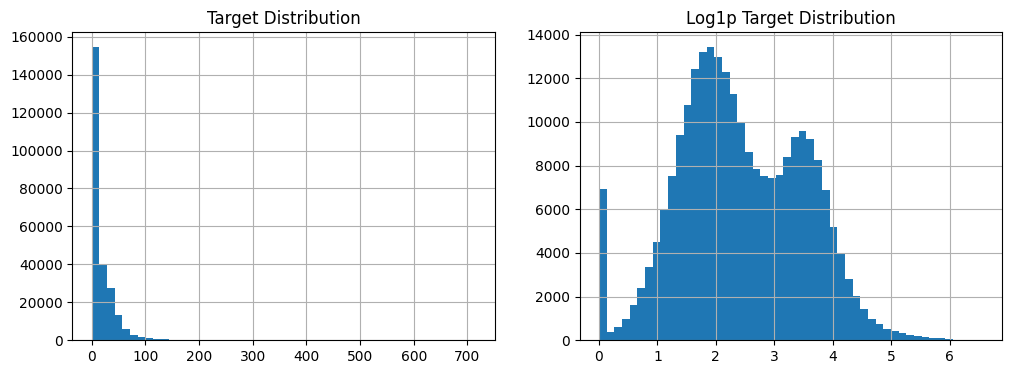

In [5]:
# Step 2: 타겟 분포 (최우선)
target = 'avg_delay_minutes_next_30m'

print(train[target].describe())
print(f"Skewness: {train[target].skew():.3f}")
print(f"Zero ratio: {(train[target]==0).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train[target].hist(bins=50, ax=axes[0])
axes[0].set_title('Target Distribution')
np.log1p(train[target]).hist(bins=50, ax=axes[1])
axes[1].set_title('Log1p Target Distribution')
plt.show()

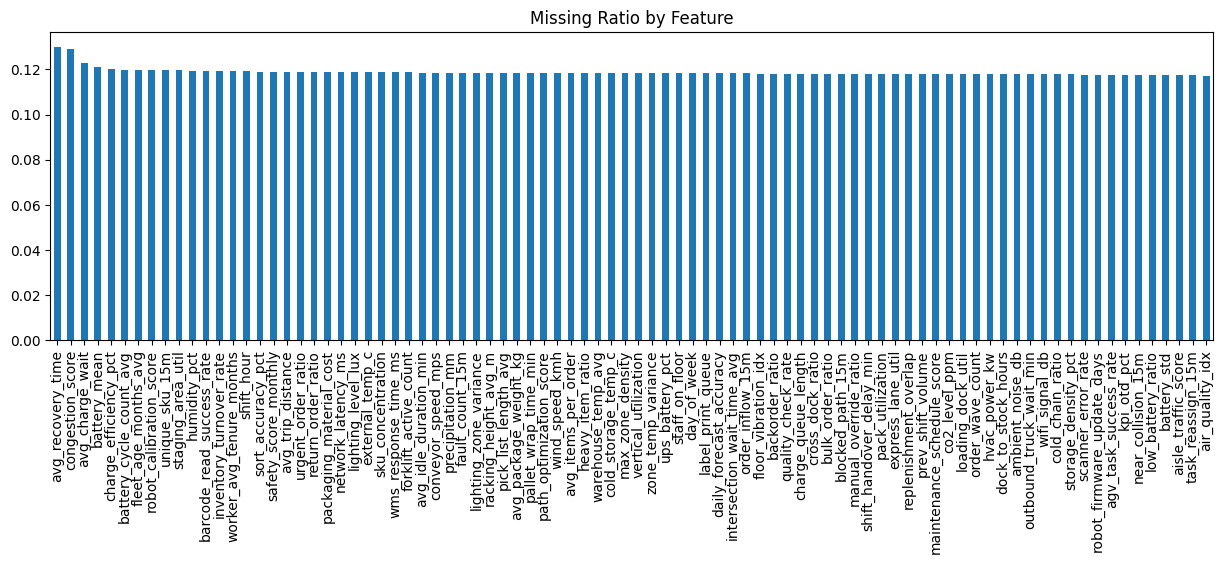

In [6]:
# Step 3: 결측치 패턴 (두 번째 우선순위)
missing_ratio = train.isnull().mean().sort_values(ascending=False)
missing_ratio[missing_ratio > 0].plot(kind='bar', figsize=(15, 4))
plt.title('Missing Ratio by Feature')
plt.show()

['ID', 'layout_id', 'scenario_id', 'order_inflow_15m', 'unique_sku_15m', 'avg_items_per_order', 'urgent_order_ratio', 'heavy_item_ratio', 'cold_chain_ratio', 'sku_concentration', 'robot_active', 'robot_idle', 'robot_charging', 'robot_utilization', 'avg_trip_distance', 'task_reassign_15m', 'battery_mean', 'battery_std', 'low_battery_ratio', 'charge_queue_length', 'avg_charge_wait', 'congestion_score', 'max_zone_density', 'blocked_path_15m', 'near_collision_15m', 'fault_count_15m', 'avg_recovery_time', 'replenishment_overlap', 'pack_utilization', 'manual_override_ratio', 'avg_delay_minutes_next_30m', 'warehouse_temp_avg', 'humidity_pct', 'day_of_week', 'external_temp_c', 'wind_speed_kmh', 'precipitation_mm', 'lighting_level_lux', 'ambient_noise_db', 'floor_vibration_idx', 'return_order_ratio', 'air_quality_idx', 'co2_level_ppm', 'hvac_power_kw', 'wms_response_time_ms', 'scanner_error_rate', 'wifi_signal_db', 'network_latency_ms', 'worker_avg_tenure_months', 'safety_score_monthly', 'label

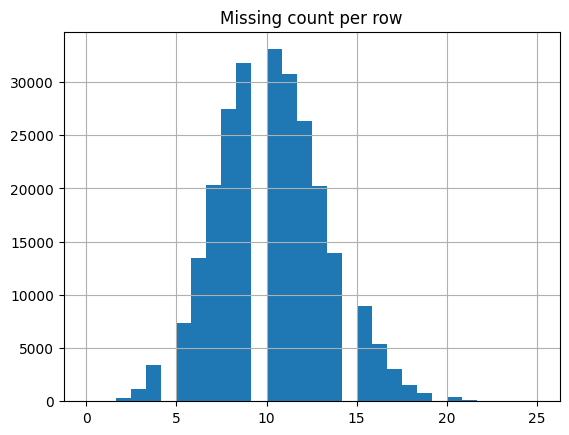

In [7]:
# 결측이 특정 time_slot에 집중되는지 확인
# scenario_id 기준 time slot 순서 컬럼 찾기
print(train.columns.tolist())  # time 관련 컬럼 확인

# 혹시 row 단위로 결측이 동시에 발생하는지
row_missing = train.isnull().sum(axis=1)
print(row_missing.describe())
row_missing.hist(bins=30)
plt.title('Missing count per row')
plt.show()

In [9]:
# 1. Row별 결측 동시 발생 패턴
row_missing = train.isnull().sum(axis=1)
print(row_missing.value_counts().head(10))

# 2. 상관관계 top features
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()['avg_delay_minutes_next_30m'].sort_values(ascending=False)

print("Top 15 positive:\n", corr.head(15))
print("Top 10 negative:\n", corr.tail(10))

# 3. time slot 관련 컬럼 확인
print([c for c in train.columns if 'time' in c.lower() or 'slot' in c.lower() or 'shift' in c.lower()])

10    33073
9     31769
11    30777
8     27417
12    26305
7     20359
13    20189
14    13899
6     13482
15     8987
Name: count, dtype: int64
Top 15 positive:
 avg_delay_minutes_next_30m    1.000000
low_battery_ratio             0.366073
order_inflow_15m              0.341754
robot_charging                0.320406
max_zone_density              0.310816
battery_std                   0.308313
congestion_score              0.300357
sku_concentration             0.291888
urgent_order_ratio            0.271079
charge_queue_length           0.261425
avg_charge_wait               0.251458
near_collision_15m            0.242848
unique_sku_15m                0.229013
blocked_path_15m              0.220499
loading_dock_util             0.213132
Name: avg_delay_minutes_next_30m, dtype: float64
Top 10 negative:
 pick_list_length_avg         -0.021878
conveyor_speed_mps           -0.065573
sort_accuracy_pct            -0.099523
kpi_otd_pct                  -0.107280
daily_forecast_accuracy     

count    220203.000000
mean          9.609628
std           5.202144
min           0.000000
25%           5.000000
50%          10.000000
75%          14.000000
max          23.000000
Name: shift_hour, dtype: float64
24
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, nan, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0]


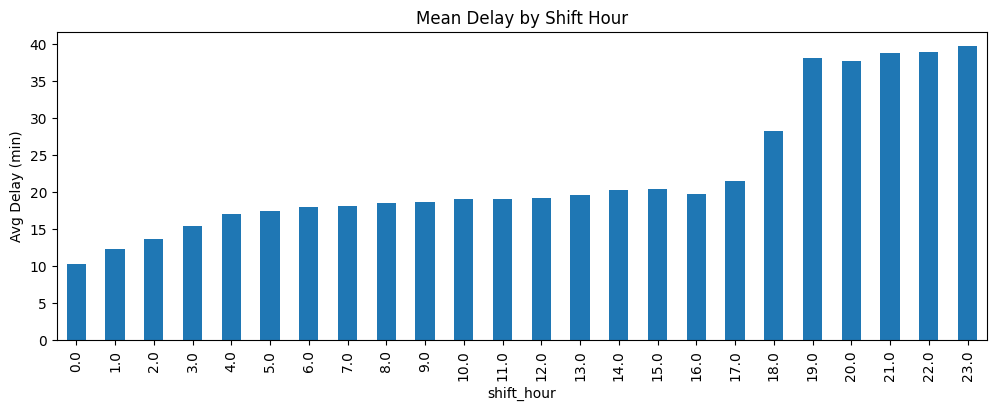

In [10]:
print(train['shift_hour'].describe())
print(train['shift_hour'].nunique())
print(sorted(train['shift_hour'].unique()))

# shift_hour별 delay 패턴
mean_delay = train.groupby('shift_hour')['avg_delay_minutes_next_30m'].mean()
mean_delay.plot(kind='bar', figsize=(12, 4))
plt.title('Mean Delay by Shift Hour')
plt.ylabel('Avg Delay (min)')
plt.show()

In [12]:
scenario_sizes = train.groupby('scenario_id').size()
print(scenario_sizes.describe())

count    10000.0
mean        25.0
std          0.0
min         25.0
25%         25.0
50%         25.0
75%         25.0
max         25.0
dtype: float64


In [13]:
sample = train[train['scenario_id'] == 'SC_07598'].sort_values('shift_hour')
print(sample[['shift_hour', 'low_battery_ratio', 'robot_charging', 'avg_delay_minutes_next_30m']].to_string())

    shift_hour  low_battery_ratio  robot_charging  avg_delay_minutes_next_30m
0          0.0             0.0000               0                    5.554758
2          0.0                NaN               0                    5.920881
7          0.0             0.0000               0                    5.266312
19         1.0             0.0000               0                    7.222998
16         1.0                NaN               0                    4.850718
13         1.0             0.0000               0                    4.041111
11         1.0             0.0000               0                    4.353057
17         3.0             0.0000               0                    4.067561
12         3.0             0.0000               0                    4.671988
1          4.0             0.0000               0                    5.039834
18         4.0             0.0000               0                    4.439753
15         5.0             0.0000               0               

In [14]:
sample = train[train['scenario_id'] == 'SC_07598'].reset_index(drop=True)
print(sample[['ID', 'shift_hour', 'avg_delay_minutes_next_30m']].to_string())

              ID  shift_hour  avg_delay_minutes_next_30m
0   TRAIN_000000         0.0                    5.554758
1   TRAIN_000001         4.0                    5.039834
2   TRAIN_000002         0.0                    5.920881
3   TRAIN_000003         6.0                    5.540926
4   TRAIN_000004         5.0                    3.940071
5   TRAIN_000005         6.0                    6.896074
6   TRAIN_000006         6.0                    6.069857
7   TRAIN_000007         0.0                    5.266312
8   TRAIN_000008         6.0                    5.819307
9   TRAIN_000009         7.0                    5.834245
10  TRAIN_000010         5.0                    7.550900
11  TRAIN_000011         1.0                    4.353057
12  TRAIN_000012         3.0                    4.671988
13  TRAIN_000013         1.0                    4.041111
14  TRAIN_000014         6.0                    5.310501
15  TRAIN_000015         5.0                   10.359620
16  TRAIN_000016         1.0   

In [16]:
# 같은 시나리오 내 다른 row들의 통계를 각 row에 붙이기
agg_features = train.groupby('scenario_id').agg(
    sc_battery_mean_avg   = ('battery_mean', 'mean'),
    sc_low_battery_max    = ('low_battery_ratio', 'max'),
    sc_congestion_avg     = ('congestion_score', 'mean'),
    sc_order_inflow_avg   = ('order_inflow_15m', 'mean'),
    sc_order_inflow_max   = ('order_inflow_15m', 'max'),
    sc_robot_charging_avg = ('robot_charging', 'mean'),
    sc_delay_mean         = ('avg_delay_minutes_next_30m', 'mean'),
).reset_index()

train = train.merge(agg_features, on='scenario_id', how='left')

# shift_hour 결측 확인 (21번 row NaN이었음)
print(train['shift_hour'].isnull().sum())
print(train.shape)

29797
(250000, 108)


In [17]:
train = train.merge(layout, on='layout_id', how='left')
print(train.shape)

(250000, 122)


In [18]:
print(train.isnull().sum()[train.isnull().sum() > 0].sort_values(ascending=False).head(10))

avg_recovery_time          32529
congestion_score           32250
avg_charge_wait            30696
battery_mean               30320
charge_efficiency_pct      30052
battery_cycle_count_avg    29955
fleet_age_months_avg       29953
robot_calibration_score    29944
unique_sku_15m             29924
staging_area_util          29892
dtype: int64


In [19]:
# 결측 indicator 먼저 생성
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
missing_cols = [col for col in numeric_cols if train[col].isnull().any()]

for col in missing_cols:
    train[f'{col}_missing'] = train[col].isnull().astype(int)

print(f"추가된 indicator 컬럼 수: {len(missing_cols)}")
print(train.shape)

추가된 indicator 컬럼 수: 86
(250000, 208)


In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
train[numeric_cols] = imputer.fit_transform(train[numeric_cols])

print(train[numeric_cols].isnull().sum().sum())

0


In [21]:
# Battery-Robot 상호작용
train['battery_robot_stress'] = train['low_battery_ratio'] * train['robot_charging']
train['charge_pressure'] = train['charge_queue_length'] / (train['robot_idle'] + 1)
train['effective_robot_ratio'] = train['robot_active'] / (train['robot_active'] + train['robot_charging'] + 1)

print(train.shape)

(250000, 211)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\132178564.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['battery_robot_stress'] = train['low_battery_ratio'] * train['robot_charging']
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\132178564.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['charge_pressure'] = train['charge_queue_length'] / (train['robot_idle'] + 1)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30876\132178564.py:4: PerformanceWarning: DataFrame is highly

In [22]:
# DataFrame 조각화 해결 + 나머지 파생변수 한번에 추가
new_features = pd.DataFrame({
    # Battery-Robot (이미 추가됐지만 재계산)
    'battery_robot_stress'  : train['low_battery_ratio'] * train['robot_charging'],
    'charge_pressure'       : train['charge_queue_length'] / (train['robot_idle'] + 1),
    'effective_robot_ratio' : train['robot_active'] / (train['robot_active'] + train['robot_charging'] + 1),
    
    # 주문-용량 압박
    'order_robot_ratio'     : train['order_inflow_15m'] / (train['robot_active'] + 1),
    'order_complexity'      : train['order_inflow_15m'] * train['avg_items_per_order'],
    'urgent_pressure'       : train['urgent_order_ratio'] * train['order_inflow_15m'],
    
    # Layout 연계
    'robots_per_area'       : train['robot_total'] / train['floor_area_sqm'],
    'charger_sufficiency'   : train['charger_count'] / train['robot_total'],
    'pack_capacity_ratio'   : train['pack_utilization'] / (train['pack_station_count'] + 1),
    
    # Shift hour
    'shift_hour_sin'        : np.sin(2 * np.pi * train['shift_hour'] / 24),
    'shift_hour_cos'        : np.cos(2 * np.pi * train['shift_hour'] / 24),
    'late_shift_flag'       : (train['shift_hour'] >= 18).astype(int),
}, index=train.index)

# 기존 3개 중복 컬럼 제거 후 concat
train = train.drop(columns=['battery_robot_stress', 'charge_pressure', 'effective_robot_ratio'])
train = pd.concat([train, new_features], axis=1)
train = train.copy()  # 조각화 해결

print(train.shape)

(250000, 220)


In [23]:
print(test.shape)

(50000, 93)


In [24]:
# 1. agg_features (train 기준으로 만든 거 test에 merge)
test = test.merge(agg_features, on='scenario_id', how='left')
print(test.shape)

(50000, 100)


In [25]:
# 2. layout merge
test = test.merge(layout, on='layout_id', how='left')
print(test.shape)

(50000, 114)


In [28]:
print([c for c in test.columns if '_x' in c or '_y' in c])
# train도 동일한 문제 있는지 확인
print([c for c in train.columns if '_x' in c or '_y' in c])

['building_age_years']
['sc_battery_mean_avg_x', 'sc_low_battery_max_x', 'sc_congestion_avg_x', 'sc_order_inflow_avg_x', 'sc_order_inflow_max_x', 'sc_robot_charging_avg_x', 'sc_delay_mean_x', 'sc_battery_mean_avg_y', 'sc_low_battery_max_y', 'sc_congestion_avg_y', 'sc_order_inflow_avg_y', 'sc_order_inflow_max_y', 'sc_robot_charging_avg_y', 'sc_delay_mean_y', 'building_age_years']


In [30]:
# 원본 다시 로드
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

print(train.shape, test.shape)

(250000, 94) (50000, 93)


In [31]:
# 1. agg_features 생성
agg_features = train.groupby('scenario_id').agg(
    sc_battery_mean_avg   = ('battery_mean', 'mean'),
    sc_low_battery_max    = ('low_battery_ratio', 'max'),
    sc_congestion_avg     = ('congestion_score', 'mean'),
    sc_order_inflow_avg   = ('order_inflow_15m', 'mean'),
    sc_order_inflow_max   = ('order_inflow_15m', 'max'),
    sc_robot_charging_avg = ('robot_charging', 'mean'),
).reset_index()

# 2. layout merge (building_age_years 중복 방지)
layout_cols = [c for c in layout.columns if c not in train.columns or c == 'layout_id']
layout_clean = layout[layout_cols]

# 3. train 전처리
train = train.merge(agg_features, on='scenario_id', how='left')
train = train.merge(layout_clean, on='layout_id', how='left')

# 4. test 전처리
test = test.merge(agg_features, on='scenario_id', how='left')
test = test.merge(layout_clean, on='layout_id', how='left')

print(train.shape, test.shape)
print([c for c in train.columns if '_x' in c or '_y' in c])

(250000, 114) (50000, 113)
['building_age_years']


In [33]:
print('building_age_years' in pd.read_csv('./data/train.csv').columns)
print('building_age_years' in layout.columns)

False
True


In [35]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# 1. agg_features 생성
agg_features = train.groupby('scenario_id').agg(
    sc_battery_mean_avg   = ('battery_mean', 'mean'),
    sc_low_battery_max    = ('low_battery_ratio', 'max'),
    sc_congestion_avg     = ('congestion_score', 'mean'),
    sc_order_inflow_avg   = ('order_inflow_15m', 'mean'),
    sc_order_inflow_max   = ('order_inflow_15m', 'max'),
    sc_robot_charging_avg = ('robot_charging', 'mean'),
).reset_index()

# 2. layout 중복 컬럼 제거 (layout_id만 key로 유지)
layout_clean = layout.drop(columns=[c for c in layout.columns 
                                     if c in train.columns and c != 'layout_id'])

# 3. merge
train = train.merge(agg_features, on='scenario_id', how='left')
train = train.merge(layout_clean, on='layout_id', how='left')

test = test.merge(agg_features, on='scenario_id', how='left')
test = test.merge(layout_clean, on='layout_id', how='left')

print(train.shape, test.shape)
print([c for c in train.columns if '_x' in c or '_y' in c])

(250000, 114) (50000, 113)
['building_age_years']


In [36]:
print(layout_clean.columns.tolist())

['layout_id', 'layout_type', 'aisle_width_avg', 'intersection_count', 'one_way_ratio', 'pack_station_count', 'charger_count', 'layout_compactness', 'zone_dispersion', 'robot_total', 'building_age_years', 'floor_area_sqm', 'ceiling_height_m', 'fire_sprinkler_count', 'emergency_exit_count']


In [37]:
train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

# 1. agg_features 생성
agg_features = train.groupby('scenario_id').agg(
    sc_battery_mean_avg   = ('battery_mean', 'mean'),
    sc_low_battery_max    = ('low_battery_ratio', 'max'),
    sc_congestion_avg     = ('congestion_score', 'mean'),
    sc_order_inflow_avg   = ('order_inflow_15m', 'mean'),
    sc_order_inflow_max   = ('order_inflow_15m', 'max'),
    sc_robot_charging_avg = ('robot_charging', 'mean'),
).reset_index()

# 2. layout 명시적 선택 (building_age_years 제외)
layout_clean = layout[['layout_id', 'layout_type', 'aisle_width_avg', 
                        'intersection_count', 'one_way_ratio', 'pack_station_count',
                        'charger_count', 'layout_compactness', 'zone_dispersion',
                        'robot_total', 'floor_area_sqm', 'ceiling_height_m',
                        'fire_sprinkler_count', 'emergency_exit_count']]

# 3. merge
train = train.merge(agg_features, on='scenario_id', how='left')
train = train.merge(layout_clean, on='layout_id', how='left')

test = test.merge(agg_features, on='scenario_id', how='left')
test = test.merge(layout_clean, on='layout_id', how='left')

print(train.shape, test.shape)
print([c for c in train.columns if '_x' in c or '_y' in c])

(250000, 113) (50000, 112)
[]


In [38]:
# 결측 indicator 생성 + median imputation
from sklearn.impute import SimpleImputer

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
missing_cols = [col for col in numeric_cols if train[col].isnull().any()]

for col in missing_cols:
    train[f'{col}_missing'] = train[col].isnull().astype(int)
    test[f'{col}_missing'] = test[col].isnull().astype(int)

imputer = SimpleImputer(strategy='median')
train[numeric_cols] = imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = imputer.transform(test[numeric_cols])

print(train.isnull().sum().sum(), test.isnull().sum().sum())
print(train.shape, test.shape)

KeyError: "['avg_delay_minutes_next_30m'] not in index"

In [39]:
numeric_cols_test = [c for c in numeric_cols if c in test.columns]

imputer = SimpleImputer(strategy='median')
train[numeric_cols] = imputer.fit_transform(train[numeric_cols])
test[numeric_cols_test] = imputer.transform(test[numeric_cols_test])

print(train.isnull().sum().sum(), test.isnull().sum().sum())
print(train.shape, test.shape)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- avg_delay_minutes_next_30m


In [40]:
target = 'avg_delay_minutes_next_30m'

numeric_cols_train = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_train_no_target = [c for c in numeric_cols_train if c != target]
numeric_cols_test = test.select_dtypes(include=[np.number]).columns.tolist()

imputer = SimpleImputer(strategy='median')
train[numeric_cols_train_no_target] = imputer.fit_transform(train[numeric_cols_train_no_target])
test[numeric_cols_test] = imputer.transform(test[numeric_cols_test])

# target은 따로 처리 (결측 없을 거지만 확인)
print(train[target].isnull().sum())
print(train.isnull().sum().sum(), test.isnull().sum().sum())
print(train.shape, test.shape)

0
0 0
(250000, 199) (50000, 198)


In [41]:
new_features_train = pd.DataFrame({
    'battery_robot_stress'  : train['low_battery_ratio'] * train['robot_charging'],
    'charge_pressure'       : train['charge_queue_length'] / (train['robot_idle'] + 1),
    'effective_robot_ratio' : train['robot_active'] / (train['robot_active'] + train['robot_charging'] + 1),
    'order_robot_ratio'     : train['order_inflow_15m'] / (train['robot_active'] + 1),
    'order_complexity'      : train['order_inflow_15m'] * train['avg_items_per_order'],
    'urgent_pressure'       : train['urgent_order_ratio'] * train['order_inflow_15m'],
    'robots_per_area'       : train['robot_total'] / train['floor_area_sqm'],
    'charger_sufficiency'   : train['charger_count'] / train['robot_total'],
    'shift_hour_sin'        : np.sin(2 * np.pi * train['shift_hour'] / 24),
    'shift_hour_cos'        : np.cos(2 * np.pi * train['shift_hour'] / 24),
    'late_shift_flag'       : (train['shift_hour'] >= 18).astype(int),
}, index=train.index)

new_features_test = pd.DataFrame({
    'battery_robot_stress'  : test['low_battery_ratio'] * test['robot_charging'],
    'charge_pressure'       : test['charge_queue_length'] / (test['robot_idle'] + 1),
    'effective_robot_ratio' : test['robot_active'] / (test['robot_active'] + test['robot_charging'] + 1),
    'order_robot_ratio'     : test['order_inflow_15m'] / (test['robot_active'] + 1),
    'order_complexity'      : test['order_inflow_15m'] * test['avg_items_per_order'],
    'urgent_pressure'       : test['urgent_order_ratio'] * test['order_inflow_15m'],
    'robots_per_area'       : test['robot_total'] / test['floor_area_sqm'],
    'charger_sufficiency'   : test['charger_count'] / test['robot_total'],
    'shift_hour_sin'        : np.sin(2 * np.pi * test['shift_hour'] / 24),
    'shift_hour_cos'        : np.cos(2 * np.pi * test['shift_hour'] / 24),
    'late_shift_flag'       : (test['shift_hour'] >= 18).astype(int),
}, index=test.index)

train = pd.concat([train, new_features_train], axis=1).copy()
test = pd.concat([test, new_features_test], axis=1).copy()

print(train.shape, test.shape)

(250000, 210) (50000, 209)


In [42]:
from sklearn.preprocessing import LabelEncoder

# object 컬럼 확인
obj_cols = train.select_dtypes(include='object').columns.tolist()
print(obj_cols)

['ID', 'layout_id', 'scenario_id', 'layout_type']


In [43]:
# layout_type 인코딩
le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'])
test['layout_type'] = le.transform(test['layout_type'])

# ID, layout_id, scenario_id 제거
drop_cols = ['ID', 'layout_id', 'scenario_id']
train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

print(train.shape, test.shape)

(250000, 207) (50000, 206)


In [44]:
from sklearn.model_selection import train_test_split

target = 'avg_delay_minutes_next_30m'

X = train.drop(columns=[target])
y = np.log1p(train[target])  # log1p 변환 (skewness 5.68 확인됐으니)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_val.shape)

(200000, 206) (50000, 206)


In [46]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

# 검증 성능
y_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE (log scale): {rmse:.4f}')

# 원래 스케일로 변환 후 RMSE
y_pred_orig = np.expm1(y_pred)
y_val_orig = np.expm1(y_val)
rmse_orig = np.sqrt(mean_squared_error(y_val_orig, y_pred_orig))
print(f'Validation RMSE (original scale): {rmse_orig:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.353861
[200]	valid_0's l2: 0.325694
[300]	valid_0's l2: 0.310443
[400]	valid_0's l2: 0.300717
[500]	valid_0's l2: 0.29418
[600]	valid_0's l2: 0.288562
[700]	valid_0's l2: 0.282419
[800]	valid_0's l2: 0.278401
[900]	valid_0's l2: 0.274959
[1000]	valid_0's l2: 0.272311
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.272311
Validation RMSE (log scale): 0.5218
Validation RMSE (original scale): 19.9402


In [47]:
# feature importance 확인
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(20))

                   feature  importance
100     pack_station_count        3495
93     sc_order_inflow_avg        3327
90     sc_battery_mean_avg        2991
94     sc_order_inflow_max        2868
92       sc_congestion_avg        2387
11       avg_trip_distance        2339
6        sku_concentration        2226
95   sc_robot_charging_avg        2111
91      sc_low_battery_max        2081
103        zone_dispersion        1883
102     layout_compactness        1820
97         aisle_width_avg        1787
105         floor_area_sqm        1741
99           one_way_ratio        1731
26   manual_override_ratio        1714
107   fire_sprinkler_count        1545
106       ceiling_height_m        1489
2      avg_items_per_order        1481
202    charger_sufficiency        1479
98      intersection_count        1442


In [48]:
model2 = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=127,
    random_state=42,
    n_jobs=-1
)

model2.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

y_pred2 = model2.predict(X_val)
rmse_orig2 = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred2)))
print(f'Validation RMSE (original scale): {rmse_orig2:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.325694
[400]	valid_0's l2: 0.300717
[600]	valid_0's l2: 0.288562
[800]	valid_0's l2: 0.278401
[1000]	valid_0's l2: 0.272311
[1200]	valid_0's l2: 0.268436
[1400]	valid_0's l2: 0.264768
[1600]	valid_0's l2: 0.26259
[1800]	valid_0's l2: 0.260777
[2000]	valid_0's l2: 0.259517
[2200]	valid_0's l2: 0.258696
[2400]	valid_0's l2: 0.257969
[2600]	valid_0's l2: 0.257227
[2800]	valid_0's l2: 0.256475
[3000]	valid_0's l2: 0.255846
Did not meet early stopping. Best iteration is:
[2997]	valid_0's l2: 0.255839
Validation RMSE (original scale): 19.4447


In [49]:
model3 = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=127,
    random_state=42,
    n_jobs=-1
)

model3.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

y_pred3 = model3.predict(X_val)
rmse_orig3 = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred3)))
print(f'Validation RMSE (original scale): {rmse_orig3:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060877 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[500]	valid_0's l2: 0.29418
[1000]	valid_0's l2: 0.272311
[1500]	valid_0's l2: 0.263705
[2000]	valid_0's l2: 0.259517
[2500]	valid_0's l2: 0.257644
[3000]	valid_0's l2: 0.255846
[3500]	valid_0's l2: 0.254993
[4000]	valid_0's l2: 0.254412
[4500]	valid_0's l2: 0.25387
[5000]	valid_0's l2: 0.253431
Did not meet early stopping. Best iteration is:
[4999]	valid_0's l2: 0.253431
Validation RMSE (original scale): 19.3705


In [51]:
import os
import joblib
os.makedirs('./models', exist_ok=True)

model4 = lgb.LGBMRegressor(
    n_estimators=10000,
    learning_rate=0.02,
    num_leaves=127,
    random_state=42,
    n_jobs=-1
)

model4.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

joblib.dump(model4, './models/lgbm_model4.pkl')

y_pred4 = model4.predict(X_val)
rmse_orig4 = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred4)))
print(f'Validation RMSE (original scale): {rmse_orig4:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.058791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[500]	valid_0's l2: 0.323327
[1000]	valid_0's l2: 0.299806
[1500]	valid_0's l2: 0.285958
[2000]	valid_0's l2: 0.276817
[2500]	valid_0's l2: 0.270186
[3000]	valid_0's l2: 0.265356
[3500]	valid_0's l2: 0.261857
[4000]	valid_0's l2: 0.259345
[4500]	valid_0's l2: 0.257197
[5000]	valid_0's l2: 0.255655
[5500]	valid_0's l2: 0.254539
[6000]	valid_0's l2: 0.253605
[6500]	valid_0's l2: 0.252842
[7000]	valid_0's l2: 0.252086
[7500]	valid_0's l2: 0.251542
[8000]	valid_0's l2: 0.251011
[8500]	valid_0's l2: 0.25061
[9000]	valid_0's l2: 0.250239
[9500]	valid_0's l2: 0.249966
[10000]	valid_0's l2: 0.2

In [52]:
model5 = lgb.LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    num_leaves=255,       # 127 → 255 증가
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

model5.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

joblib.dump(model5, './models/lgbm_model5.pkl')

y_pred5 = model5.predict(X_val)
rmse_orig5 = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred5)))
print(f'Validation RMSE (original scale): {rmse_orig5:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054638 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[500]	valid_0's l2: 0.269133
[1000]	valid_0's l2: 0.254919
[1500]	valid_0's l2: 0.250511
[2000]	valid_0's l2: 0.248665
[2500]	valid_0's l2: 0.247635
[3000]	valid_0's l2: 0.247091
[3500]	valid_0's l2: 0.246755
[4000]	valid_0's l2: 0.246576
[4500]	valid_0's l2: 0.246457
[5000]	valid_0's l2: 0.246342
Did not meet early stopping. Best iteration is:
[4998]	valid_0's l2: 0.246342
Validation RMSE (original scale): 19.3119


In [53]:
model6 = lgb.LGBMRegressor(
    n_estimators=10000,
    learning_rate=0.05,
    num_leaves=511,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

model6.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)]
)

joblib.dump(model6, './models/lgbm_model6.pkl')

y_pred6 = model6.predict(X_val)
rmse_orig6 = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(y_pred6)))
print(f'Validation RMSE (original scale): {rmse_orig6:.4f}')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055376 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24820
[LightGBM] [Info] Number of data points in the train set: 200000, number of used features: 206
[LightGBM] [Info] Start training from score 2.423409
Training until validation scores don't improve for 100 rounds
[500]	valid_0's l2: 0.254471
[1000]	valid_0's l2: 0.248566
[1500]	valid_0's l2: 0.247015
[2000]	valid_0's l2: 0.246394
[2500]	valid_0's l2: 0.246176
[3000]	valid_0's l2: 0.246061
[3500]	valid_0's l2: 0.246009
[4000]	valid_0's l2: 0.245975
[4500]	valid_0's l2: 0.245961
[5000]	valid_0's l2: 0.245953
Early stopping, best iteration is:
[5249]	valid_0's l2: 0.24595
Validation RMSE (original scale): 19.3267


In [54]:
# test 예측 후 submission 생성
test_id = pd.read_csv('./data/test.csv')['ID']

y_test_pred = model5.predict(test)
y_test_pred_orig = np.expm1(y_test_pred)

submission = pd.DataFrame({
    'ID': test_id,
    'avg_delay_minutes_next_30m': y_test_pred_orig
})

submission.to_csv('./submission_model5.csv', index=False)
print(submission.shape)
print(submission.head())

(50000, 2)
            ID  avg_delay_minutes_next_30m
0  TEST_000000                   13.437466
1  TEST_000001                   11.992806
2  TEST_000002                   13.246282
3  TEST_000003                   15.118200
4  TEST_000004                   12.146705


In [56]:
# 원본에서 scenario_id 가져오기
scenario_id_train = pd.read_csv('./data/train.csv')['scenario_id']

train['scenario_id'] = scenario_id_train.values
train['sc_delay_mean_loo'] = (
    train.groupby('scenario_id')['avg_delay_minutes_next_30m']
    .transform(lambda x: (x.sum() - x) / (x.count() - 1))
)

print(train['sc_delay_mean_loo'].describe())

count    250000.000000
mean         18.962296
std          21.794810
min           0.000000
25%           4.611397
50%           9.561479
75%          27.503643
max         235.771676
Name: sc_delay_mean_loo, dtype: float64
